In [17]:
import pandas as pd

df = pd.read_csv('20_newsgroups_as_table.csv')

In [18]:
print(df.head())
print(df.shape)

                                                text                  target
0  From: lerxst@wam.umd.edu (where's my thing)\nS...         rec.motorcycles
1  From: guykuo@carson.u.washington.edu (Guy Kuo)...          comp.windows.x
2  From: twillis@ec.ecn.purdue.edu (Thomas E Will...          comp.windows.x
3  From: jgreen@amber (Joe Green)\nSubject: Re: W...           comp.graphics
4  From: jcm@head-cfa.harvard.edu (Jonathan McDow...  soc.religion.christian
(11314, 2)


In [20]:
#When creating a classifier we need to split our data into 
#training and test sets
#we train on a portion of the data and test on another portion of the data
#important that these samples are performed randomly 
train = df.sample(frac = 0.8)
test = df.drop(train.index)
print(train.shape)
print(test.shape)

(9051, 2)
(2263, 2)


In [22]:
#sklearn is a very large library
#therefore we typically import only the functions we are actually going to use
from sklearn.feature_extraction.text import CountVectorizer

#A 'vectorizer' turns text data into a numeric matrix
#which can then be used by the model
vectorizer = CountVectorizer()
train_vectors = vectorizer.fit_transform(train['text'])
test_vectors = vectorizer.transform(test['text'])
#nb diff between transform and fit transform

In [23]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(train_vectors, train['target'])
test['pred'] = clf.predict(test_vectors)

In [24]:
test.head()

,text,target,pred
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,comp.graphics,talk.religion.misc
11,From: david@terminus.ericsson.se (David Bold)\...,comp.os.ms-windows.misc,comp.os.ms-windows.misc
16,From: ab@nova.cc.purdue.edu (Allen B)\nSubject...,comp.graphics,comp.graphics
19,From: abarden@tybse1.uucp (Ann Marie Barden)\n...,misc.forsale,comp.windows.x
20,From: keith@cco.caltech.edu (Keith Allan Schne...,alt.atheism,alt.atheism


In [25]:
#definitions can be found here: 
#https://medium.com/@shrutisaxena0617/precision-vs-recall-386cf9f89488
from sklearn import metrics
print(metrics.accuracy_score(test['target'], test['pred']))
print(metrics.precision_score(test['target'], test['pred'], average='macro'))
print(metrics.recall_score(test['target'], test['pred'], average='macro'))

0.4692885550154662
0.5446934132443542
0.4739510842950576


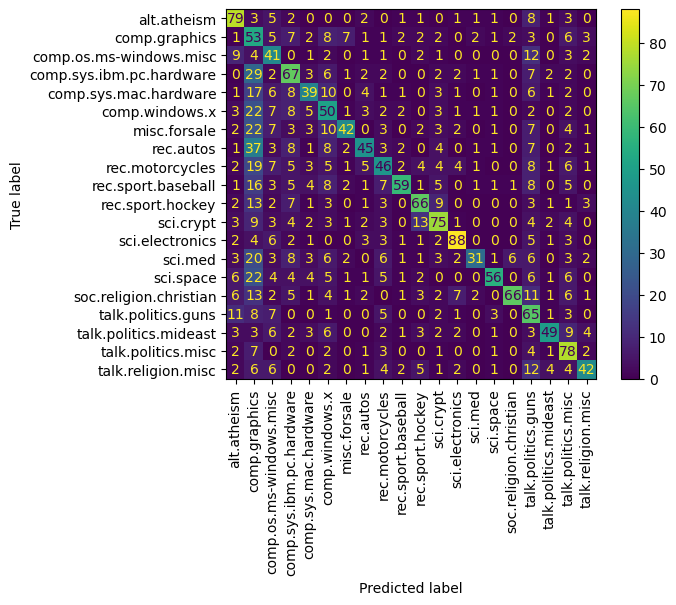

In [16]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test['target'], test['pred'], labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=clf.classes_)
disp.plot(xticks_rotation = 'vertical')
plt.show()